In [201]:
import sys

sys.path.append("../")
from rad_odometry.icp_sparse_odometry import icpSparseOdometry
from rad_odometry.kalman_filter import ExtendedKalmanFilter
from rad_odometry.test_bench import testBench
import math
import numpy as np
import matplotlib.pyplot as plt
import os

## Available Datasets and Maps

In [202]:
# datasets listed by their respective maps
dataset_folder = "/data/radnav/rad_nav_experiments"


dataset_path = "/data/radnav/rad_nav_vel_experiments/vel_test_cpsl_0_2_mps_person/"

## Velocity Class:
creating a new velocity class to determine the velocity of the UGV from a point cloud with [x,y,z,vel] coordinates

In [203]:
class simpleTestBench:
    def __init__(self, dataset_path, radar_folder):

        self.dataset_path = dataset_path
        self.radar_folder = radar_folder
        self.radar_files = []

        # define plot parameters:
        self.font_size_axis_labels = 12
        self.font_size_title = 15
        self.font_size_ticks = 12
        self.font_size_legend = 12
        self.plot_x_max = 10
        self.plot_y_max = 20

        self.import_dataset_files()

    def import_dataset_files(self):
        # get radar file paths
        path = os.path.join(self.dataset_path, self.radar_folder)
        self.radar_files = sorted(os.listdir(path))
        print("found {} radar samples".format(len(self.radar_files)))

    def get_radar_detections(self, idx):

        path = os.path.join(self.dataset_path, self.radar_folder, self.radar_files[idx])
        points = np.load(path)

        # filter out zero indicies
        points = self.filter_zero_vels(points)

        points = self.filter_high_vels(points)

        return points

    def filter_zero_vels(self, points):

        return points[np.absolute(points[:, 3]) > 0.03]

    def filter_high_vels(self, points):

        return points[np.absolute(points[:, 3]) < 0.5]

    def remove_self_detections(self, points):

        distances = np.linalg.norm(points, axis=1)
        self_detection_idxs = distances < 0.5

        return points[~self_detection_idxs, :]

    def plot_detections(self, detections, ax: plt.Axes = None, show=True):

        # create a plot
        if not ax:
            fig, ax = plt.subplots()

        ax.scatter(
            detections[:, 0],
            detections[:, 1],
            label="current: {} points".format(detections.shape[0]),
            marker="D",
            color="blue",
        )
        ax.set_title("Radar Detections", fontsize=self.font_size_title)
        ax.set_xlim(-1 * self.plot_x_max, self.plot_x_max)
        ax.set_xlabel("X", fontsize=self.font_size_axis_labels)
        ax.set_ylim(-1 * self.plot_y_max, self.plot_y_max)
        ax.set_ylabel("Y", fontsize=self.font_size_axis_labels)
        ax.tick_params(labelsize=self.font_size_ticks)
        ax.xaxis.set_major_locator(plt.MultipleLocator(5.0))
        ax.yaxis.set_major_locator(plt.MultipleLocator(5.0))
        ax.grid("True")

        if show:
            plt.show()


class LSQ_vel:
    def __init__(self):

        self.v = None

        return

    def fit(self, detections: np.ndarray, vels: np.ndarray):

        # get matrix of target positions
        P = detections

        # compute the r vectors (p/||p|| for each row in P)
        H = np.divide(P, np.linalg.norm(P, axis=1).reshape(-1, 1))

        y = vels
        # v,res,rank,s = np.linalg.lstsq(H,y,rcond=None)
        v = np.linalg.inv(H.T @ H) @ H.T @ y

        self.v = v

    def predict(self, detections: np.ndarray):

        # get matrix of target positions
        P = detections[:, 0:3]

        # compute the r vectors (p/||p|| for each row in P)
        H = np.divide(P, np.linalg.norm(P, axis=1).reshape(-1, 1))

        return H @ self.v

In [204]:
from copy import copy
import numpy as np
from numpy.random import default_rng

rng = default_rng()


class RANSAC:
    def __init__(self, n=3, k=100, t=0.05, d=10, model=None, loss=None, metric=None):
        self.n = n  # `n`: Minimum number of data points to estimate parameters
        self.k = k  # `k`: Maximum iterations allowed
        self.t = t  # `t`: Threshold value to determine if points are fit well
        self.d = (
            d  # `d`: Number of close data points required to assert model fits well
        )
        self.model = model  # `model`: class implementing `fit` and `predict`
        self.loss = (
            loss  # `loss`: function of `y_true` and `y_pred` that returns a vector
        )
        self.metric = (
            metric  # `metric`: function of `y_true` and `y_pred` and returns a float
        )
        self.best_fit = None
        self.best_error = np.inf

    def fit(self, X, y):

        for _ in range(self.k):
            ids = rng.permutation(X.shape[0])

            maybe_inliers = ids[: self.n]
            maybe_model = copy(self.model)
            maybe_model.fit(X[maybe_inliers], y[maybe_inliers])

            thresholded = (
                self.loss(y[ids][self.n :], maybe_model.predict(X[ids][self.n :]))
                < self.t
            )

            inlier_ids = ids[self.n :][np.flatnonzero(thresholded).flatten()]

            if inlier_ids.size > self.d:
                inlier_points = np.hstack([maybe_inliers, inlier_ids])
                better_model = copy(self.model)
                better_model.fit(X[inlier_points], y[inlier_points])

                this_error = self.metric(
                    y[inlier_points], better_model.predict(X[inlier_points])
                )

                if this_error < self.best_error:
                    self.best_error = this_error
                    self.best_fit = better_model

        return self

    def predict(self, X):
        return self.best_fit.predict(X)


def square_error_loss(y_true, y_pred):
    return (y_true - y_pred) ** 2


def mean_square_error(y_true, y_pred):
    return np.sum(square_error_loss(y_true, y_pred)) / y_true.shape[0]

In [205]:
test_bench = simpleTestBench(dataset_path=dataset_path, radar_folder="radar_combined")

found 607 radar samples


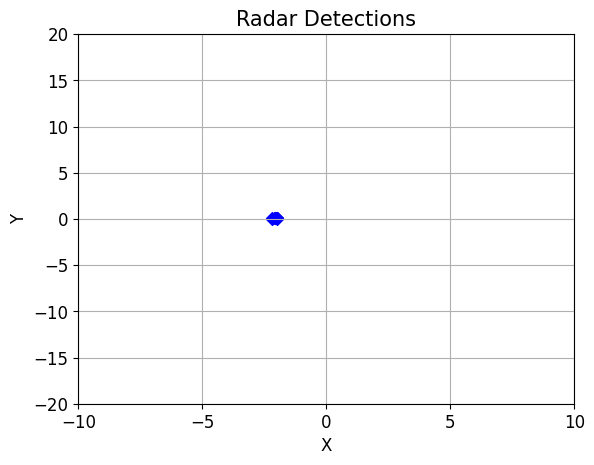

In [206]:
idx = 0

detections = test_bench.get_radar_detections(idx)
test_bench.plot_detections(detections)

In [207]:
print(detections)

[[-1.9773438e+00  5.4687500e-02  0.0000000e+00  4.2081755e-02]
 [-2.0750000e+00  5.8593750e-02  0.0000000e+00  4.2081755e-02]
 [-2.1726563e+00 -3.6237107e-16  0.0000000e+00  4.2081755e-02]
 [-1.9773438e+00 -3.2649274e-16  0.0000000e+00  8.4163509e-02]
 [-2.0750000e+00  5.8593750e-02  0.0000000e+00  8.4163509e-02]
 [-1.9773438e+00  5.4687500e-02  0.0000000e+00 -7.0136257e-02]
 [-2.0750000e+00  5.8593750e-02  0.0000000e+00 -7.0136257e-02]
 [-2.1726563e+00  6.2500000e-02  0.0000000e+00 -7.0136257e-02]
 [-1.9773438e+00  5.4687500e-02  0.0000000e+00 -4.2081755e-02]
 [-2.0750000e+00  5.8593750e-02  0.0000000e+00 -4.2081755e-02]]


(-0.5, 0.5)

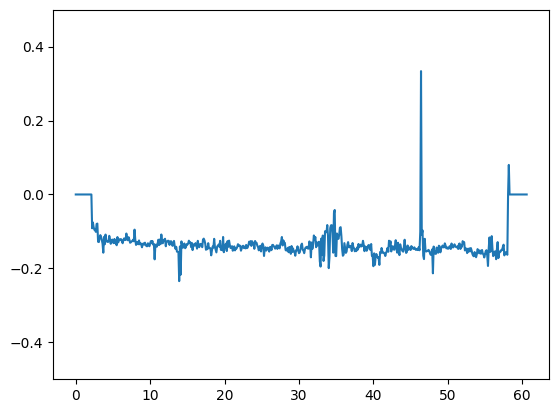

In [210]:
x_vels = []
y_vels = []

for i in range(len(test_bench.radar_files)):
    detections = test_bench.get_radar_detections(i)

    if detections.shape[0] > 7:
        regressor = RANSAC(
            model=LSQ_vel(),
            loss=square_error_loss,
            metric=mean_square_error,
            n=7,
            k=20,
            t=1.5e-2,
            d=5,
        )

        regressor.fit(detections[:, 0:2], detections[:, 3])
        best_model = regressor.best_fit

        if best_model:
            x_vels.append(best_model.v[0])
            y_vels.append(best_model.v[1])
        else:
            x_vels.append(0)
            y_vels.append(0)

    else:
        x_vels.append(0)
        y_vels.append(0)

t = 0.1 * np.arange(len(test_bench.radar_files))
plt.plot(t, x_vels)
plt.ylim((-0.5, 0.5))

Debugging/trials

In [209]:
# #initialize the model
# lsq_vel = LSQ_vel()

# X = detections[:,0:2]
# y = detections[:,3].reshape(-1,1)
# n = 3 #initial number of data points
# thresh = 1.5e-2
# iters = 17

# for i in range(iters):
#     #take a random sample
#     rng = np.random.default_rng()
#     idxs = rng.permutation(X.shape[0])
#     #print(idxs)

#     #fit the model
#     initial_inliers = idxs[:n]
#     lsq_vel.fit(X[initial_inliers],y[initial_inliers])
#     #print(lsq_vel.v)

#     #get predictions for all detections
#     y_predict = lsq_vel.predict(X[idxs][n:])

#     errors = square_error_loss(y[idxs][n:],y_predict)
#     inliers = errors < thresh
#     inlier_ids = idxs[n:][np.flatnonzero(inliers).flatten()]
#     total_inliers = inlier_ids.shape[0]

#     #refit the model
#     combined_inliers = np.hstack([initial_inliers,inlier_ids])
#     lsq_vel.fit(X[combined_inliers],y[combined_inliers])

#     #get the total model error
#     y_predict = lsq_vel.predict(X[combined_inliers])
#     error = mean_square_error(y[combined_inliers],y_predict)
#     print("\n\niteration: {}".format(i))
#     print("inliers: {}\nerror: {}\nfinal fit:\n {}".format(total_inliers,error,lsq_vel.v))